In [2]:
# Basic libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Preprocessing
from sklearn.preprocessing import StandardScaler

# Model selection
from sklearn.model_selection import train_test_split

# Models
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor

# Evaluation metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
# Load dataset
data = pd.read_csv("abc.csv")

# Display first 5 rows
data.head()

,City,Household_Size,Seasonal_Index,Garden_Area,Avg_Rainfall,Household_Income,Previous_Day_Usage,City_Population,Daily_Water_Used,Avg_Water_Table,Suitability
0,Pune,3.0,1.105,179.345,650.0,66700.0,271.400,7300000.0,266.357,520.0,Suitable
1,Chennai,4.0,0.500,93.100,1400.0,69900.0,125.583,11000000.0,122.500,1120.0,Suitable
2,Jaipur,2.0,NaN,19.800,550.0,97900.0,124.016,3500000.0,NaN,440.0,Suitable
3,Kolkata,2.0,1.050,44.330,1600.0,40000.0,219.800,14800000.0,219.946,1280.0,Suitable
4,Pune,1.0,1.140,136.012,650.0,82300.0,256.036,7300000.0,257.690,520.0,Suitable


In [4]:
# Check shape (rows, columns)
print("Shape:", data.shape)
data.info()
data.describe()
data.isnull().sum()

Shape: (200000, 11)
<class 'pandas.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   City                200000 non-null  str    
 1   Household_Size      189851 non-null  float64
 2   Seasonal_Index      190039 non-null  float64
 3   Garden_Area         189882 non-null  float64
 4   Avg_Rainfall        190025 non-null  float64
 5   Household_Income    189881 non-null  float64
 6   Previous_Day_Usage  190170 non-null  float64
 7   City_Population     190088 non-null  float64
 8   Daily_Water_Used    189915 non-null  float64
 9   Avg_Water_Table     189987 non-null  float64
 10  Suitability         190088 non-null  str    
dtypes: float64(9), str(2)
memory usage: 16.8 MB


City                      0
Household_Size        10149
Seasonal_Index         9961
Garden_Area           10118
Avg_Rainfall           9975
Household_Income      10119
Previous_Day_Usage     9830
City_Population        9912
Daily_Water_Used      10085
Avg_Water_Table       10013
Suitability            9912
dtype: int64

In [5]:
# Fill numerical columns with median
data.fillna(data.median(numeric_only=True), inplace=True)
# Fill categorical column with mode
data["Suitability"] = data["Suitability"].fillna(data["Suitability"].mode()[0])
data.isnull().sum()

City                  0
Household_Size        0
Seasonal_Index        0
Garden_Area           0
Avg_Rainfall          0
Household_Income      0
Previous_Day_Usage    0
City_Population       0
Daily_Water_Used      0
Avg_Water_Table       0
Suitability           0
dtype: int64

In [6]:
print(data.columns)

Index(['City', 'Household_Size', 'Seasonal_Index', 'Garden_Area',
       'Avg_Rainfall', 'Household_Income', 'Previous_Day_Usage',
       'City_Population', 'Daily_Water_Used', 'Avg_Water_Table',
       'Suitability'],
      dtype='str')


In [7]:
data = pd.get_dummies(data, columns=["City"], drop_first=True)
print(data.columns)

Index(['Household_Size', 'Seasonal_Index', 'Garden_Area', 'Avg_Rainfall',
       'Household_Income', 'Previous_Day_Usage', 'City_Population',
       'Daily_Water_Used', 'Avg_Water_Table', 'Suitability', 'City_Bangalore',
       'City_Chennai', 'City_Delhi', 'City_Hyderabad', 'City_Jaipur',
       'City_Kolkata', 'City_Lucknow', 'City_Mumbai', 'City_Pune'],
      dtype='str')


In [8]:
# Format numerical columns

data["Household_Size"] = data["Household_Size"].round().astype(int)

data["Seasonal_Index"] = data["Seasonal_Index"].round(3)
data["Garden_Area"] = data["Garden_Area"].round(3)
data["Previous_Day_Usage"] = data["Previous_Day_Usage"].round(3)
data["Daily_Water_Used"] = data["Daily_Water_Used"].round(3)

# Round income to nearest 100
data["Household_Income"] = (data["Household_Income"] / 100).round() * 100

In [9]:
import numpy as np

# Select numerical columns
num_cols = data.select_dtypes(include=np.number).columns

# Calculate Q1, Q3, IQR
Q1 = data[num_cols].quantile(0.25)
Q3 = data[num_cols].quantile(0.75)
IQR = Q3 - Q1

# Remove outliers
data = data[~((data[num_cols] < (Q1 - 1.5 * IQR)) | 
              (data[num_cols] > (Q3 + 1.5 * IQR))).any(axis=1)]

# Check shape
print("Shape after outlier removal:", data.shape)

Shape after outlier removal: (196002, 19)


In [10]:


# 6. Feature and Target Split

X = data.drop(["Daily_Water_Used", "Suitability", "Avg_Water_Table"], axis=1)
y = data["Daily_Water_Used"]


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [18]:
print(X_train.shape)
print(X_test.shape)

(156801, 16)
(39201, 16)


In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit on training data
X_train = scaler.fit_transform(X_train)

# Transform test data
X_test = scaler.transform(X_test)

print(X_train.shape)
print(X_test.shape)


(156801, 16)
(39201, 16)


In [13]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [14]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
print(y_pred_rf)

[156.43603 241.92143 110.23108 ... 135.71345 207.8886  143.81503]


In [ ]:
from sklearn.neighbors import KNeighborsRegressor

knn = KNeighborsRegressor()
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)
print(y_pred_knn)

In [ ]:
from sklearn.svm import SVR

svr = SVR()
svr.fit(X_train, y_train)

y_pred_svr = svr.predict(X_test)
print(y_pred_svr)

In [17]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
# Linear Regression
mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)
print(y_test,y_pred_lr)
# Random Forest
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)
print(y_test,y_pred_rf)
# KNN
mae_knn = mean_absolute_error(y_test, y_pred_knn)
mse_knn = mean_squared_error(y_test, y_pred_knn)
r2_knn = r2_score(y_test, y_pred_knn)
print(y_test,y_pred_knn)
# SVR
mae_svr = mean_absolute_error(y_test, y_pred_svr)
mse_svr = mean_squared_error(y_test, y_pred_svr)
r2_svr = r2_score(y_test, y_pred_svr)
print(y_test,y_pred_svr)

In [19]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "KNN", "SVR"],
    "MAE": [mae_lr, mae_rf, mae_knn, mae_svr],
    "MSE": [mse_lr, mse_rf, mse_knn, mse_svr],
    "R2 Score": [r2_lr, r2_rf, r2_knn, r2_svr]
})

results

,Model,MAE,MSE,R2 Score
0,Linear Regression,8.784523,328.625886,0.897611
1,Random Forest,9.617106,349.191263,0.891203
2,KNN,13.021314,438.398353,0.863409
3,SVR,8.771361,338.931214,0.894400


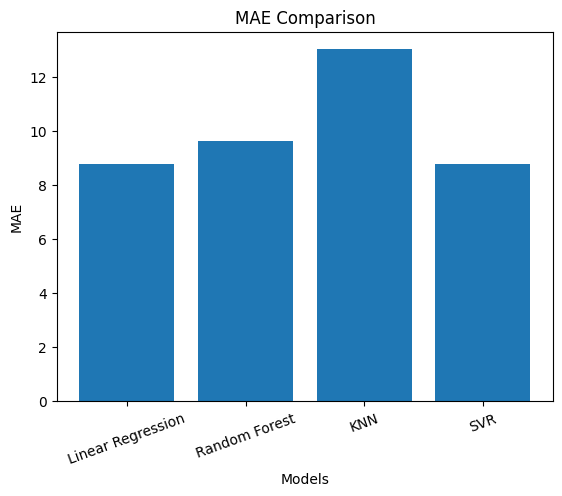

In [20]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(results["Model"], results["MAE"])
plt.title("MAE Comparison")
plt.xlabel("Models")
plt.ylabel("MAE")
plt.xticks(rotation=20)
plt.show()

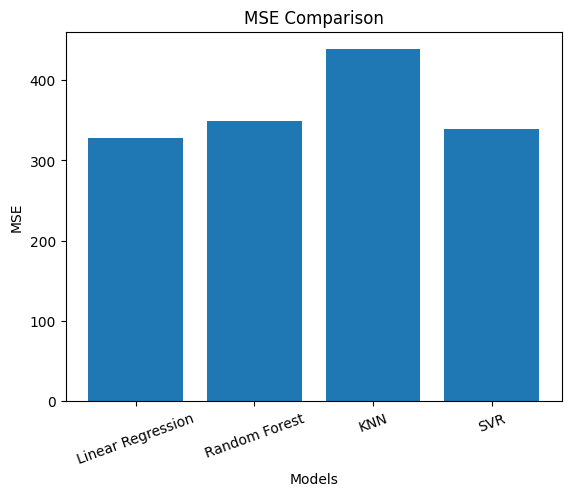

In [21]:
plt.figure()
plt.bar(results["Model"], results["MSE"])
plt.title("MSE Comparison")
plt.xlabel("Models")
plt.ylabel("MSE")
plt.xticks(rotation=20)
plt.show()

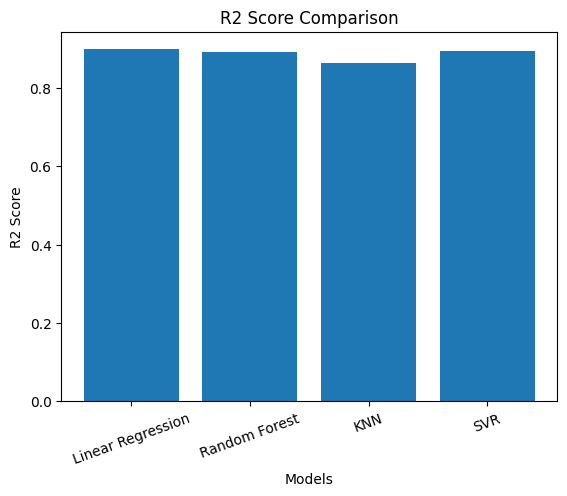

In [22]:
plt.figure()
plt.bar(results["Model"], results["R2 Score"])
plt.title("R2 Score Comparison")
plt.xlabel("Models")
plt.ylabel("R2 Score")
plt.xticks(rotation=20)
plt.show()

In [23]:
# Normalize metrics
results["MAE_norm"] = results["MAE"] / results["MAE"].max()
results["MSE_norm"] = results["MSE"] / results["MSE"].max()
results["R2_norm"] = results["R2 Score"] / results["R2 Score"].max()

# Final score
results["Final_Score"] = (
    (1 - results["MAE_norm"]) +
    (1 - results["MSE_norm"]) +
    results["R2_norm"]
)

# Best model
best_model = results.sort_values(by="Final_Score", ascending=False)
best_model.head(1)

,Model,MAE,MSE,R2 Score,MAE_norm,MSE_norm,R2_norm,Final_Score
0,Linear Regression,8.784523,328.625886,0.897611,0.674626,0.749606,1.0,1.575768


In [24]:
best_model_name = best_model.iloc[0]["Model"]
print("Best Model:", best_model_name)

Best Model: Linear Regression


In [25]:
if best_model_name == "Linear Regression":
    final_model = lr
elif best_model_name == "Random Forest":
    final_model = rf
elif best_model_name == "KNN":
    final_model = knn
else:
    final_model = svr

In [ ]:
print("\n========= ENTER DETAILS =========")

# Numeric inputs
household_size = int(input("Household Size: "))
seasonal_index = float(input("Seasonal Index: "))
garden_area = float(input("Garden Area: "))
avg_rainfall = float(input("Average Rainfall: "))
household_income = int(input("Household Income: "))
prev_usage = float(input("Previous Day Usage: "))
city_population = int(input("City Population: "))

# City input (IMPORTANT)
city = input("Enter City (e.g., Delhi, Mumbai, Pune): ")

# Create input dictionary
user_input = {
    "Household_Size": household_size,
    "Seasonal_Index": seasonal_index,
    "Garden_Area": garden_area,
    "Avg_Rainfall": avg_rainfall,
    "Household_Income": household_income,
    "Previous_Day_Usage": prev_usage,
    "City_Population": city_population
}

# Handle encoded city columns
for col in X.columns:
    if "City_" in col:
        user_input[col] = 1 if col == f"City_{city}" else 0

# Convert to DataFrame
import pandas as pd
input_df = pd.DataFrame([user_input])

# Ensure correct column order
input_df = input_df[X.columns]

# Apply scaling
input_scaled = scaler.transform(input_df)

# Prediction
prediction = final_model.predict(input_scaled)

print("\n Predicted Daily Water Usage:", prediction[0])


========= ENTER DETAILS =========

✅ Predicted Daily Water Usage: 228.78466428416547


In [29]:
original_data = pd.read_csv("abc.csv")
import numpy as np

water_table = original_data["Avg_Water_Table"].sample(1).values[0]
water_table = original_data["Avg_Water_Table"].mean()
if prediction[0] <= water_table:
    suitability = "Suitable"
else:
    suitability = "Not Suitable"

print("\nPredicted Daily Water Usage:", round(prediction[0], 2))
print("Water Table (from dataset):", round(water_table, 2))
print("Suitability (Current Year):", suitability)


Predicted Daily Water Usage: 228.78
Water Table (from dataset): 844.88
Suitability (Current Year): Suitable


In [39]:
print("\n========= 5 YEAR FORECAST =========")

population_growth = 1.02
water_decline = 0.97
usage_growth = 1.01

# Initial values
current_population = city_population
current_water_table = water_table
current_usage = prediction[0]

for year in range(1, 6):

    # Update values
    current_population *= population_growth
    current_water_table *= water_decline
    current_usage *= usage_growth

    # Update input for model
    future_input = input_df.copy()

    future_input["City_Population"] = current_population
    future_input["Previous_Day_Usage"] = current_usage

    # Scale
    future_scaled = scaler.transform(future_input)

    # Predict again using model
    future_prediction = final_model.predict(future_scaled)[0]

    # Suitability check
    if future_prediction <= current_water_table:
        suitability = "Suitable"
    else:
        suitability = "Not Suitable"

    # Output
    print(f"\nYear {year}")
    print("Predicted Usage:", round(future_prediction, 2))
    print("Water Table:", round(current_water_table, 2))
    print("Suitability:", suitability)


========= 5 YEAR FORECAST =========

Year 1
Predicted Usage: 229.77
Water Table: 819.53
Suitability: Suitable

Year 2
Predicted Usage: 231.96
Water Table: 794.95
Suitability: Suitable

Year 3
Predicted Usage: 234.18
Water Table: 771.1
Suitability: Suitable

Year 4
Predicted Usage: 236.42
Water Table: 747.96
Suitability: Suitable

Year 5
Predicted Usage: 238.68
Water Table: 725.53
Suitability: Suitable


In [47]:
years = []
usage_list = []
water_list = []
for year in range(1, 6):

    current_population *= population_growth
    current_water_table *= water_decline
    current_usage *= usage_growth

    # Update input
    future_input = input_df.copy()
    future_input["City_Population"] = current_population
    future_input["Previous_Day_Usage"] = current_usage

    # Scale + predict
    future_scaled = scaler.transform(future_input)
    future_prediction = final_model.predict(future_scaled)[0]

    # Store values
    years.append(year)
    usage_list.append(future_prediction)
    water_list.append(current_water_table)

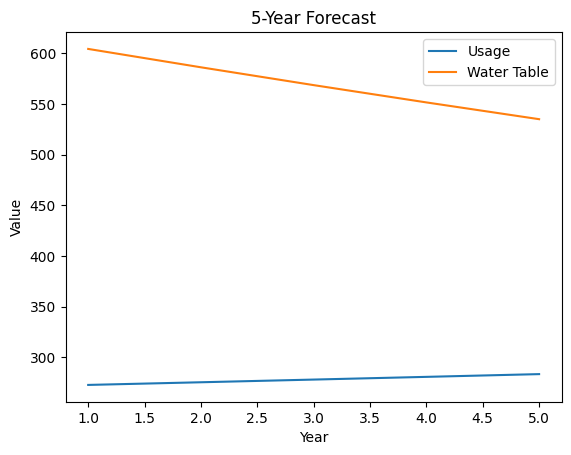

In [48]:
plt.figure()

plt.plot(years, usage_list, label="Usage")
plt.plot(years, water_list, label="Water Table")

plt.legend()
plt.title("5-Year Forecast")
plt.xlabel("Year")
plt.ylabel("Value")
plt.show()

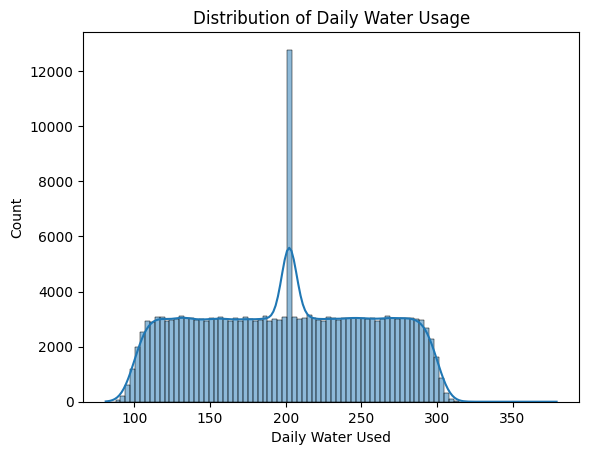

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure()
sns.histplot(data["Daily_Water_Used"], kde=True)
plt.title("Distribution of Daily Water Usage")
plt.xlabel("Daily Water Used")
plt.ylabel("Count")
plt.show()

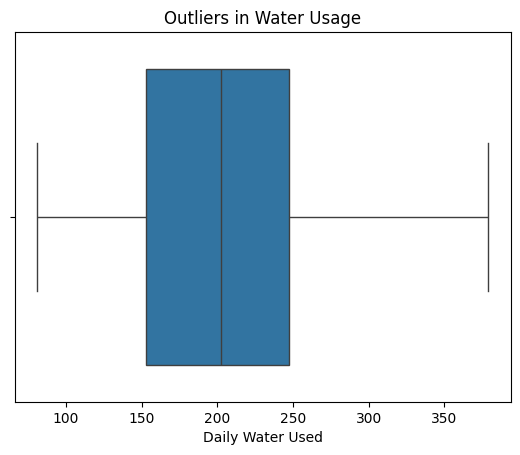

In [32]:
plt.figure()
sns.boxplot(x=data["Daily_Water_Used"])
plt.title("Outliers in Water Usage")
plt.xlabel("Daily Water Used")
plt.show()

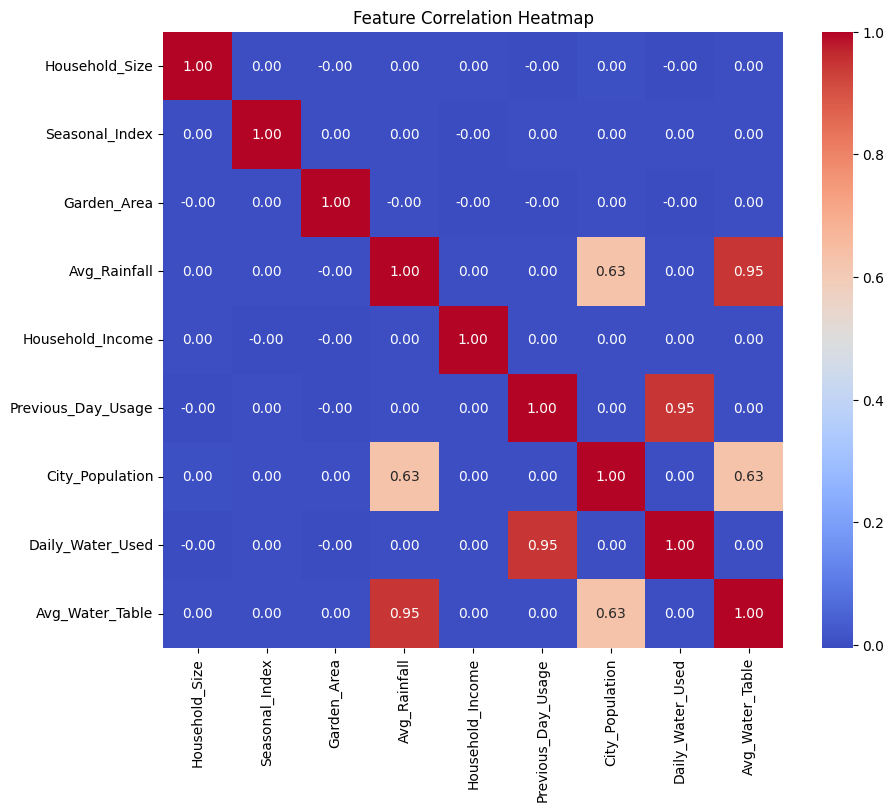

In [33]:
import numpy as np

plt.figure(figsize=(10, 8))
sns.heatmap(data.select_dtypes(include=np.number).corr(),
            annot=True,
            cmap="coolwarm",
            fmt=".2f")

plt.title("Feature Correlation Heatmap")
plt.show()

In [1]:
original_data = pd.read_csv("abc.csv")
plt.figure()

original_data.groupby("City")["Daily_Water_Used"].mean().plot(kind="bar")

plt.title("Average Water Usage by City")
plt.xlabel("City")
plt.ylabel("Liters")
plt.xticks(rotation=45)
plt.show()


NameError: name 'pd' is not defined